# Sentiment Analysis - Study 2b

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import json
import re
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

/opt/homebrew/Caskroom/miniforge/base/envs/tft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tqdm.pandas()

## Reading & cleaning the LLM responses

In [2]:
df = pd.read_csv('./data/ageRisk_complete.csv', index_col=0)

## Feature engineering

In [5]:
def get_oneshot_classes(df, classes, col, prefix):
    for label in classes:
        df[f'{prefix}-{label}'] = df[col].apply(lambda x: x['scores'][x['labels'].index(label)])
    return df

### Presence of a disclaimer

In [6]:
zero_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidates_disclaimer = ['disclaimer', 'no disclaimer']

df_disclaimer = df.copy()
df_disclaimer['disclaimer_raw'] = df_disclaimer['raw'].progress_apply(lambda res: zero_classifier(res, candidates_disclaimer))

100%|█████████████████████████████████████████| 180/180 [05:04<00:00,  1.69s/it]


In [7]:
df_disclaimer = get_oneshot_classes(df_disclaimer, candidates_disclaimer, 'disclaimer_raw', 'disclaim')
df = df_disclaimer

### Presence of explanations

In [9]:
candidates_explanations = ['explanations', 'no explanations']

df_explanations = df.copy()
df_explanations['explanations_raw'] = df_explanations['raw'].progress_apply(lambda res: zero_classifier(res, candidates_explanations))

100%|█████████████████████████████████████████| 180/180 [05:12<00:00,  1.74s/it]


In [10]:
df_explanations = get_oneshot_classes(df_explanations, candidates_explanations, 'explanations_raw', 'explain')
df = df_explanations

### Assertiveness

In [11]:
candidates_assertive = ['assertive', 'non-assertive']

df_assertive = df.copy()
df_assertive['assertiveness_raw'] = df_assertive['raw'].progress_apply(lambda res: zero_classifier(res, candidates_assertive))

100%|█████████████████████████████████████████| 180/180 [05:35<00:00,  1.86s/it]


In [12]:
df_assertive = get_oneshot_classes(df_assertive, candidates_assertive, 'assertiveness_raw', 'assertive')
df = df_assertive

In [13]:
df.to_csv('./data/sentiment_features.csv')

## Analysis

In [21]:
df = pd.read_csv('./data/sentiment_features.csv', index_col=0)
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')
df['cond'] = df['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})
df['risk_taking'] = df['risk_taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})

In [22]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk_taking':'Risk Tendency'}
rename_dict = {
    'disclaim_disclaimer' : 'Disclaimer',
    'disclaim_no_disclaimer':'No Disclaimer',
    'assertive_assertive':'Assertiveness',
    'assertive_non_assertive':'Non-Assertiveness',
    'explain_explanations':'Rationality',
    'explain_no_explanations':'Non-Rationality',  
}   

def show_colmeans(df, starter):
    for column_name in df.columns:
        if column_name.startswith(starter):
            print(f'mean for column {rename_dict[column_name]}: {round(df[column_name].mean(), 4)} with length: {df[column_name].size}')

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
def show_errplot(raw, column, column_label, group1, group2=None):
    if group1 == 'risk_taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
        
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    
    grouped = raw.groupby(groups, observed=False)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    
    plt.clf()
    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
        
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 4), zorder=2, color=colors)
    ax.set_ylabel(rename_dict[column_label])
    x_label = 'Condition' if group1 == 'cond' else label_dict.get(group1, group1)
    ax.set_xlabel(x_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.grid(True, zorder=1)
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/sentiment/{group1}{group2_label}-{column_label}.png', bbox_inches='tight')
    
def show_model_details(df, starter, group1, group2=None):
    for column_name in df.columns:
        if column_name.startswith(starter):            
            show_errplot(df, column_name, column_name, group1, group2)
            plt.show()

### Disclaimer

In [23]:
show_colmeans(df, 'disclaim_')

mean for column Disclaimer: 0.9462 with length: 180
mean for column No Disclaimer: 0.0538 with length: 180


            sum_sq     df          F    PR(>F)
label     0.028627    1.0  11.018415  0.001094
Residual  0.462459  178.0        NaN       NaN
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Control prompt Debiased prompt  -0.0252 0.0011 -0.0402 -0.0102   True
---------------------------------------------------------------------
means:
cond
Control prompt     0.9588
Debiased prompt    0.9336
Name: disclaim_disclaimer, dtype: float64
stds:
cond
Control prompt     0.0419
Debiased prompt    0.0587
Name: disclaim_disclaimer, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: disclaim_disclaimer, dtype: int64


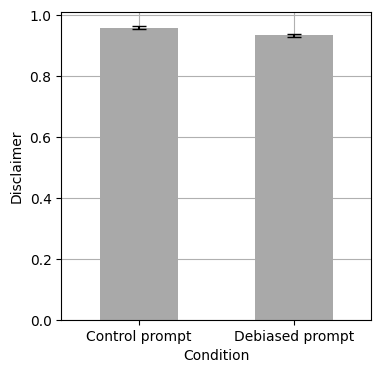

            sum_sq     df         F    PR(>F)
label     0.028627    1.0  11.01842  0.001094
Residual  0.462459  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt   0.0252 0.0011 0.0102 0.0402   True
-------------------------------------------------------------------
means:
cond
Control prompt     0.0412
Debiased prompt    0.0664
Name: disclaim_no_disclaimer, dtype: float64
stds:
cond
Control prompt     0.0419
Debiased prompt    0.0587
Name: disclaim_no_disclaimer, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: disclaim_no_disclaimer, dtype: int64


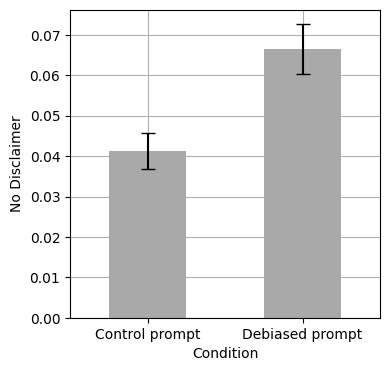

In [24]:
show_model_details(df, 'disclaim_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.001367    1.0  0.496819  0.481823
Residual  0.489719  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0008 0.9966 -0.0234 0.0219  False
    15     50   0.0064 0.7833 -0.0163 0.0291  False
    30     50   0.0071 0.7372 -0.0155 0.0298  False
---------------------------------------------------
means:
age
15    0.9443
30    0.9436
50    0.9507
Name: disclaim_disclaimer, dtype: float64
stds:
age
15    0.0524
30    0.0572
50    0.0477
Name: disclaim_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_disclaimer, dtype: int64


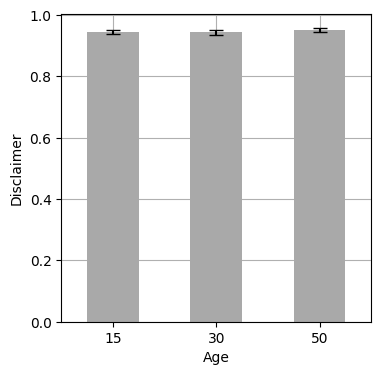

            sum_sq     df         F    PR(>F)
label     0.001367    1.0  0.496819  0.481823
Residual  0.489719  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0008 0.9966 -0.0219 0.0234  False
    15     50  -0.0064 0.7833 -0.0291 0.0163  False
    30     50  -0.0071 0.7372 -0.0298 0.0155  False
---------------------------------------------------
means:
age
15    0.0557
30    0.0564
50    0.0493
Name: disclaim_no_disclaimer, dtype: float64
stds:
age
15    0.0524
30    0.0572
50    0.0477
Name: disclaim_no_disclaimer, dtype: float64
age
15    60
30    60
50    60
Name: disclaim_no_disclaimer, dtype: int64


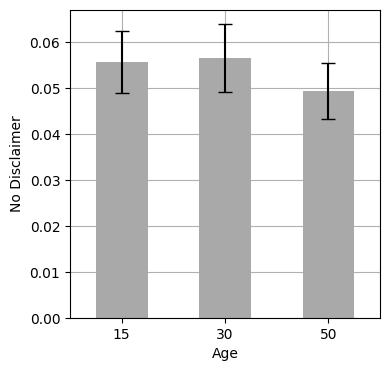

In [25]:
show_model_details(df, 'disclaim_', 'age')

            sum_sq     df          F    PR(>F)
label     0.050249    2.0  10.087823  0.000071
Residual  0.440836  177.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0401 0.0001 -0.0616 -0.0185   True
  high medium  -0.0127 0.3436 -0.0343  0.0088  False
   low medium   0.0273 0.0087  0.0058  0.0488   True
----------------------------------------------------
means:
risk_taking
low       0.9237
medium    0.9510
high      0.9638
Name: disclaim_disclaimer, dtype: float64
stds:
risk_taking
low       0.0624
medium    0.0520
high      0.0295
Name: disclaim_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_disclaimer, dtype: int64


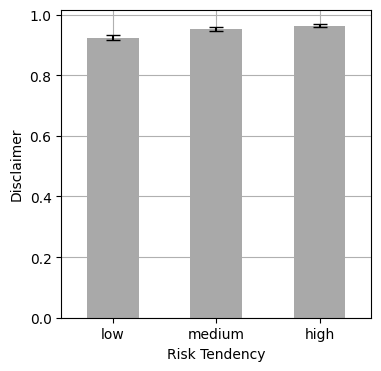

            sum_sq     df         F    PR(>F)
label     0.050249    2.0  10.08782  0.000071
Residual  0.440836  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low   0.0401 0.0001  0.0185  0.0616   True
  high medium   0.0127 0.3436 -0.0088  0.0343  False
   low medium  -0.0273 0.0087 -0.0488 -0.0058   True
----------------------------------------------------
means:
risk_taking
low       0.0763
medium    0.0490
high      0.0362
Name: disclaim_no_disclaimer, dtype: float64
stds:
risk_taking
low       0.0624
medium    0.0520
high      0.0295
Name: disclaim_no_disclaimer, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: disclaim_no_disclaimer, dtype: int64


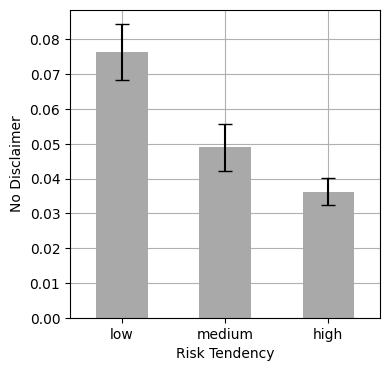

In [26]:
show_model_details(df, 'disclaim_', 'risk_taking')

            sum_sq     df         F        PR(>F)
label     0.091925    5.0  8.014262  8.021692e-07
Residual  0.399161  174.0       NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -0.0325 0.0963 -0.0681  0.0032  False
  (Control prompt, high)  (Control prompt, medium)   0.0079 0.9881 -0.0278  0.0435  False
  (Control prompt, high)   (Debiased prompt, high)  -0.0064 0.9953 -0.0421  0.0292  False
  (Control prompt, high)    (Debiased prompt, low)  -0.0541 0.0003 -0.0897 -0.0184   True
  (Control prompt, high) (Debiased prompt, medium)  -0.0398 0.0189 -0.0754 -0.0042   True
   (Control prompt, low)  (Control prompt, medium)   0.0404 0.0165  0.0047   0.076   True
   (Control prompt, low)   (Debiased pro

<Figure size 640x480 with 0 Axes>

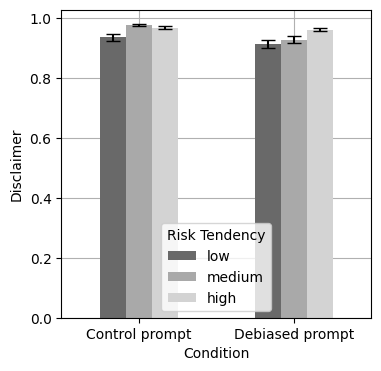

            sum_sq     df         F        PR(>F)
label     0.091925    5.0  8.014262  8.021682e-07
Residual  0.399161  174.0       NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)   0.0325 0.0963 -0.0032  0.0681  False
  (Control prompt, high)  (Control prompt, medium)  -0.0079 0.9881 -0.0435  0.0278  False
  (Control prompt, high)   (Debiased prompt, high)   0.0064 0.9953 -0.0292  0.0421  False
  (Control prompt, high)    (Debiased prompt, low)   0.0541 0.0003  0.0184  0.0897   True
  (Control prompt, high) (Debiased prompt, medium)   0.0398 0.0189  0.0042  0.0754   True
   (Control prompt, low)  (Control prompt, medium)  -0.0404 0.0165  -0.076 -0.0047   True
   (Control prompt, low)   (Debiased pro

<Figure size 640x480 with 0 Axes>

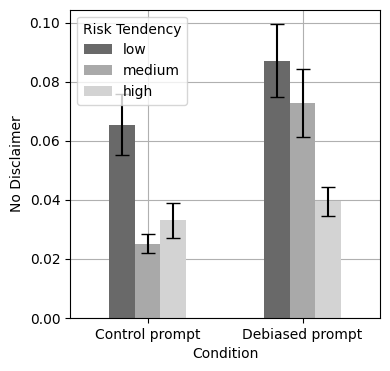

In [27]:
show_model_details(df, 'disclaim_', 'cond', 'risk_taking')

### Explanations

In [28]:
show_colmeans(df, 'explain_')

mean for column Rationality: 0.9602 with length: 180
mean for column Non-Rationality: 0.0398 with length: 180


            sum_sq     df         F    PR(>F)
label     0.000621    1.0  1.083963  0.299225
Residual  0.101942  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.0037 0.2992 -0.0108 0.0033  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.9620
Debiased prompt    0.9583
Name: explain_explanations, dtype: float64
stds:
cond
Control prompt     0.0227
Debiased prompt    0.0251
Name: explain_explanations, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: explain_explanations, dtype: int64


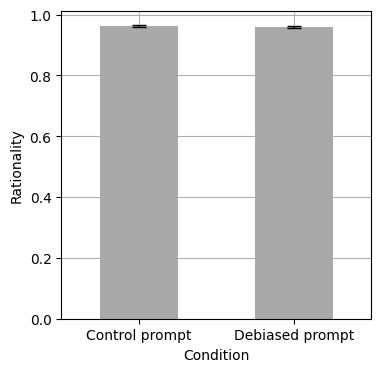

            sum_sq     df        F    PR(>F)
label     0.000621    1.0  1.08396  0.299226
Residual  0.101942  178.0      NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt   0.0037 0.2992 -0.0033 0.0108  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.0380
Debiased prompt    0.0417
Name: explain_no_explanations, dtype: float64
stds:
cond
Control prompt     0.0227
Debiased prompt    0.0251
Name: explain_no_explanations, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: explain_no_explanations, dtype: int64


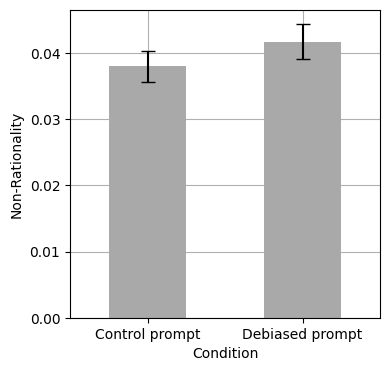

In [29]:
show_model_details(df, 'explain_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.000073    1.0  0.126284  0.722738
Residual  0.102490  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0031 0.7615 -0.0135 0.0073  False
    15     50  -0.0018 0.9141 -0.0121 0.0086  False
    30     50   0.0013 0.9516 -0.0091 0.0117  False
---------------------------------------------------
means:
age
15    0.9618
30    0.9587
50    0.9600
Name: explain_explanations, dtype: float64
stds:
age
15    0.0235
30    0.0273
50    0.0209
Name: explain_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_explanations, dtype: int64


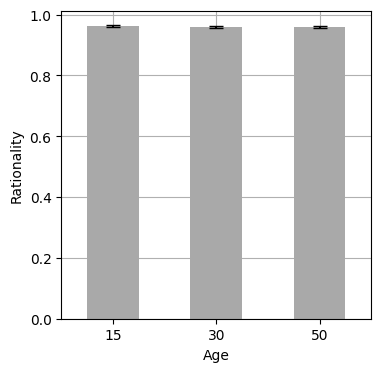

            sum_sq     df         F    PR(>F)
label     0.000073    1.0  0.126283  0.722738
Residual  0.102490  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0031 0.7615 -0.0073 0.0135  False
    15     50   0.0018 0.9141 -0.0086 0.0121  False
    30     50  -0.0013 0.9516 -0.0117 0.0091  False
---------------------------------------------------
means:
age
15    0.0382
30    0.0413
50    0.0400
Name: explain_no_explanations, dtype: float64
stds:
age
15    0.0235
30    0.0273
50    0.0209
Name: explain_no_explanations, dtype: float64
age
15    60
30    60
50    60
Name: explain_no_explanations, dtype: int64


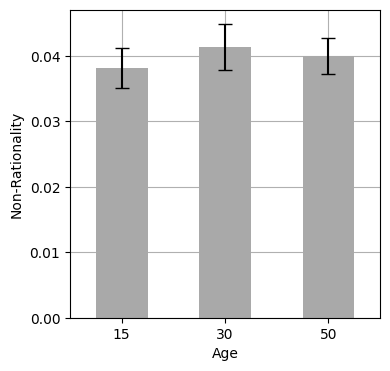

In [30]:
show_model_details(df, 'explain_', 'age')

            sum_sq     df         F    PR(>F)
label     0.000085    2.0  0.073678  0.928999
Residual  0.102477  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0016 0.9258 -0.0087  0.012  False
  high medium   0.0011  0.963 -0.0092 0.0115  False
   low medium  -0.0005  0.993 -0.0109 0.0099  False
---------------------------------------------------
means:
risk_taking
low       0.9609
medium    0.9604
high      0.9592
Name: explain_explanations, dtype: float64
stds:
risk_taking
low       0.0251
medium    0.0217
high      0.0253
Name: explain_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_explanations, dtype: int64


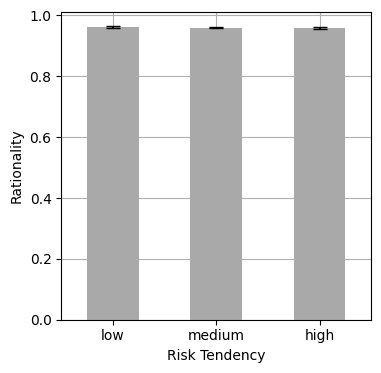

            sum_sq     df         F    PR(>F)
label     0.000085    2.0  0.073678  0.928999
Residual  0.102477  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0016 0.9258  -0.012 0.0087  False
  high medium  -0.0011  0.963 -0.0115 0.0092  False
   low medium   0.0005  0.993 -0.0099 0.0109  False
---------------------------------------------------
means:
risk_taking
low       0.0391
medium    0.0396
high      0.0408
Name: explain_no_explanations, dtype: float64
stds:
risk_taking
low       0.0251
medium    0.0217
high      0.0253
Name: explain_no_explanations, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: explain_no_explanations, dtype: int64


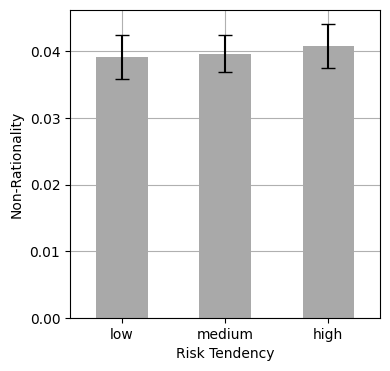

In [31]:
show_model_details(df, 'explain_', 'risk_taking')

### Assertiveness

In [32]:
show_colmeans(df, 'assertive_')

mean for column Assertiveness: 0.6172 with length: 180
mean for column Non-Assertiveness: 0.3828 with length: 180


            sum_sq     df         F    PR(>F)
label     0.020435    1.0  1.329887  0.250372
Residual  2.735175  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt   0.0213 0.2504 -0.0152 0.0578  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.6065
Debiased prompt    0.6278
Name: assertive_assertive, dtype: float64
stds:
cond
Control prompt     0.1197
Debiased prompt    0.1281
Name: assertive_assertive, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: assertive_assertive, dtype: int64


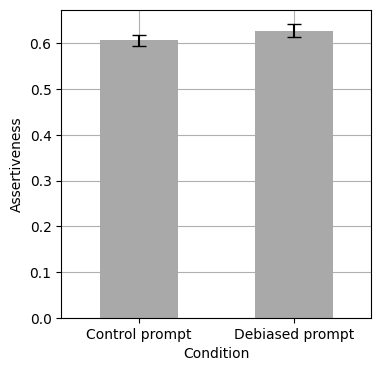

            sum_sq     df         F    PR(>F)
label     0.020435    1.0  1.329887  0.250372
Residual  2.735176  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.0213 0.2504 -0.0578 0.0152  False
--------------------------------------------------------------------
means:
cond
Control prompt     0.3935
Debiased prompt    0.3722
Name: assertive_non_assertive, dtype: float64
stds:
cond
Control prompt     0.1197
Debiased prompt    0.1281
Name: assertive_non_assertive, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: assertive_non_assertive, dtype: int64


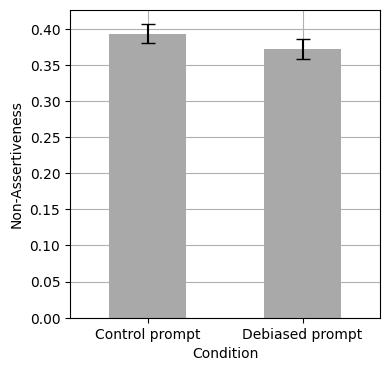

In [33]:
show_model_details(df, 'assertive_', 'cond')

            sum_sq     df         F    PR(>F)
label     0.001352    1.0  0.087396  0.767859
Residual  2.754258  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0064 0.9577 -0.0474 0.0602  False
    15     50    0.007 0.9491 -0.0468 0.0608  False
    30     50   0.0006 0.9996 -0.0532 0.0545  False
---------------------------------------------------
means:
age
15    0.6127
30    0.6191
50    0.6197
Name: assertive_assertive, dtype: float64
stds:
age
15    0.1081
30    0.1311
50    0.1334
Name: assertive_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_assertive, dtype: int64


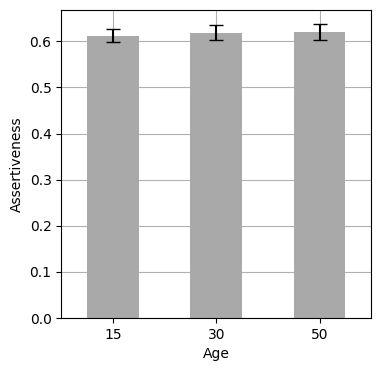

            sum_sq     df         F    PR(>F)
label     0.001352    1.0  0.087396  0.767859
Residual  2.754258  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0064 0.9577 -0.0602 0.0474  False
    15     50   -0.007 0.9491 -0.0608 0.0468  False
    30     50  -0.0006 0.9996 -0.0545 0.0532  False
---------------------------------------------------
means:
age
15    0.3873
30    0.3809
50    0.3803
Name: assertive_non_assertive, dtype: float64
stds:
age
15    0.1081
30    0.1311
50    0.1334
Name: assertive_non_assertive, dtype: float64
age
15    60
30    60
50    60
Name: assertive_non_assertive, dtype: int64


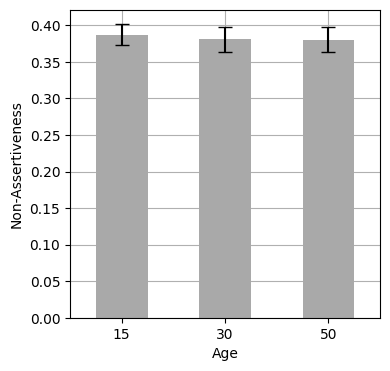

In [34]:
show_model_details(df, 'assertive_', 'age')

            sum_sq     df         F    PR(>F)
label     0.157102    2.0  5.350594  0.005544
Residual  2.598508  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low   0.0049  0.973 -0.0474  0.0572  False
  high medium  -0.0601 0.0198 -0.1123 -0.0078   True
   low medium   -0.065 0.0104 -0.1173 -0.0127   True
----------------------------------------------------
means:
risk_taking
low       0.6405
medium    0.5755
high      0.6356
Name: assertive_assertive, dtype: float64
stds:
risk_taking
low       0.1246
medium    0.1195
high      0.1193
Name: assertive_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_assertive, dtype: int64


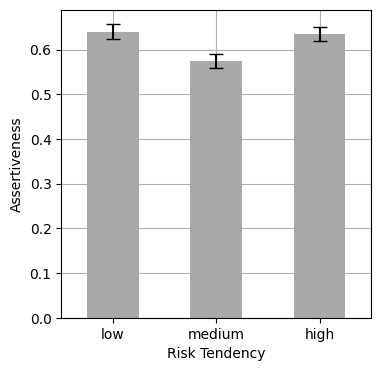

            sum_sq     df         F    PR(>F)
label     0.157102    2.0  5.350597  0.005544
Residual  2.598508  177.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0049  0.973 -0.0572 0.0474  False
  high medium   0.0601 0.0198  0.0078 0.1123   True
   low medium    0.065 0.0104  0.0127 0.1173   True
---------------------------------------------------
means:
risk_taking
low       0.3595
medium    0.4245
high      0.3644
Name: assertive_non_assertive, dtype: float64
stds:
risk_taking
low       0.1246
medium    0.1195
high      0.1193
Name: assertive_non_assertive, dtype: float64
risk_taking
low       60
medium    60
high      60
Name: assertive_non_assertive, dtype: int64


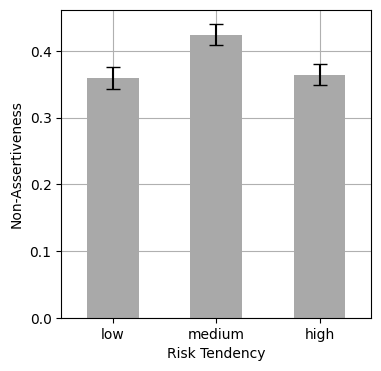

In [35]:
show_model_details(df, 'assertive_', 'risk_taking')

            sum_sq     df        F    PR(>F)
label     0.187666    5.0  2.54319  0.029965
Residual  2.567945  174.0      NaN       NaN
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower  upper  reject
----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -0.0103 0.9995 -0.1007 0.0801  False
  (Control prompt, high)  (Control prompt, medium)  -0.0766 0.1479  -0.167 0.0138  False
  (Control prompt, high)   (Debiased prompt, high)   0.0001    1.0 -0.0902 0.0905  False
  (Control prompt, high)    (Debiased prompt, low)   0.0203 0.9872 -0.0701 0.1107  False
  (Control prompt, high) (Debiased prompt, medium)  -0.0434  0.737 -0.1338  0.047  False
   (Control prompt, low)  (Control prompt, medium)  -0.0663 0.2852 -0.1567 0.0241  False
   (Control prompt, low)   (Debiased prompt, high)   0.0104 0.99

<Figure size 640x480 with 0 Axes>

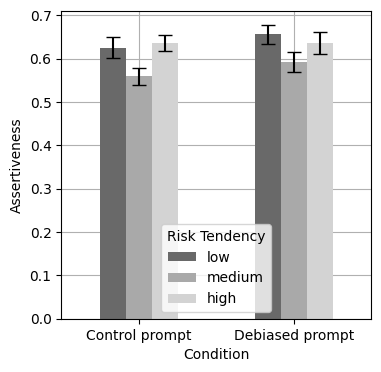

            sum_sq     df         F    PR(>F)
label     0.187666    5.0  2.543191  0.029965
Residual  2.567945  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)   0.0103 0.9995 -0.0801  0.1007  False
  (Control prompt, high)  (Control prompt, medium)   0.0766 0.1479 -0.0138   0.167  False
  (Control prompt, high)   (Debiased prompt, high)  -0.0001    1.0 -0.0905  0.0902  False
  (Control prompt, high)    (Debiased prompt, low)  -0.0203 0.9872 -0.1107  0.0701  False
  (Control prompt, high) (Debiased prompt, medium)   0.0434  0.737  -0.047  0.1338  False
   (Control prompt, low)  (Control prompt, medium)   0.0663 0.2852 -0.0241  0.1567  False
   (Control prompt, low)   (Debiased prompt, high)  

<Figure size 640x480 with 0 Axes>

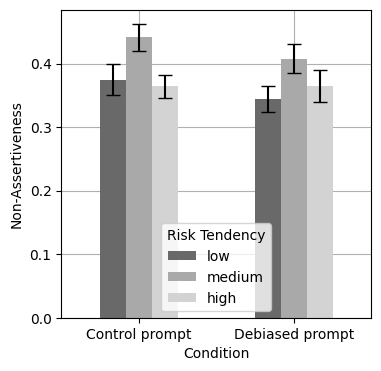

In [36]:
show_model_details(df, 'assertive_', 'cond', 'risk_taking')